(300, 100, 100)
[8 6 8 4 6 8 6 6 6 4 8 6 4 4 4 8 6 4 8 4 4 4 4 4 4 8 8 6 4 8 6 6 6 6 4 4 4
 4 4 4 6 4 8 8 8 4 8 6 6 6 6 4 8 6 6 4 6 6 4 6 4 6 8 8 4 8 6 4 6 8 6 6 8 6
 6 8 6 6 6 8 8 4 8 4 6 4 6 6 4 8 4 8 6 6 4 4 4 4 8 4 5 0 0 5 5 5 5 0 0 0 0
 5 0 0 0 5 0 0 5 0 0 5 5 0 0 5 0 5 0 5 0 5 0 5 0 0 5 5 5 0 0 0 0 0 5 5 0 0
 5 5 5 0 5 0 5 5 5 5 5 0 5 5 5 5 5 5 5 0 0 0 5 0 0 0 5 5 5 5 0 0 5 5 5 0 5
 5 5 5 5 0 0 5 0 5 0 5 0 0 5 0 2 2 3 2 9 9 2 1 9 7 1 9 9 9 9 1 3 7 7 2 3 7
 2 9 9 2 9 9 2 3 9 0 2 1 9 1 9 9 2 9 1 1 9 2 2 7 2 9 2 1 2 9 2 1 9 2 9 9 1
 9 9 9 7 2 2 2 2 1 2 2 2 3 1 5 9 9 2 1 9 9 2 9 1 2 9 9 9 7 7 2 2 9 2 3 1 7
 1 2 7 9]
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32), array([48, 16, 31,  6, 37, 54, 37, 10, 26, 35]))


C:\Users\박중현\AppData\Local\Temp\ipykernel_15344\746778690.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


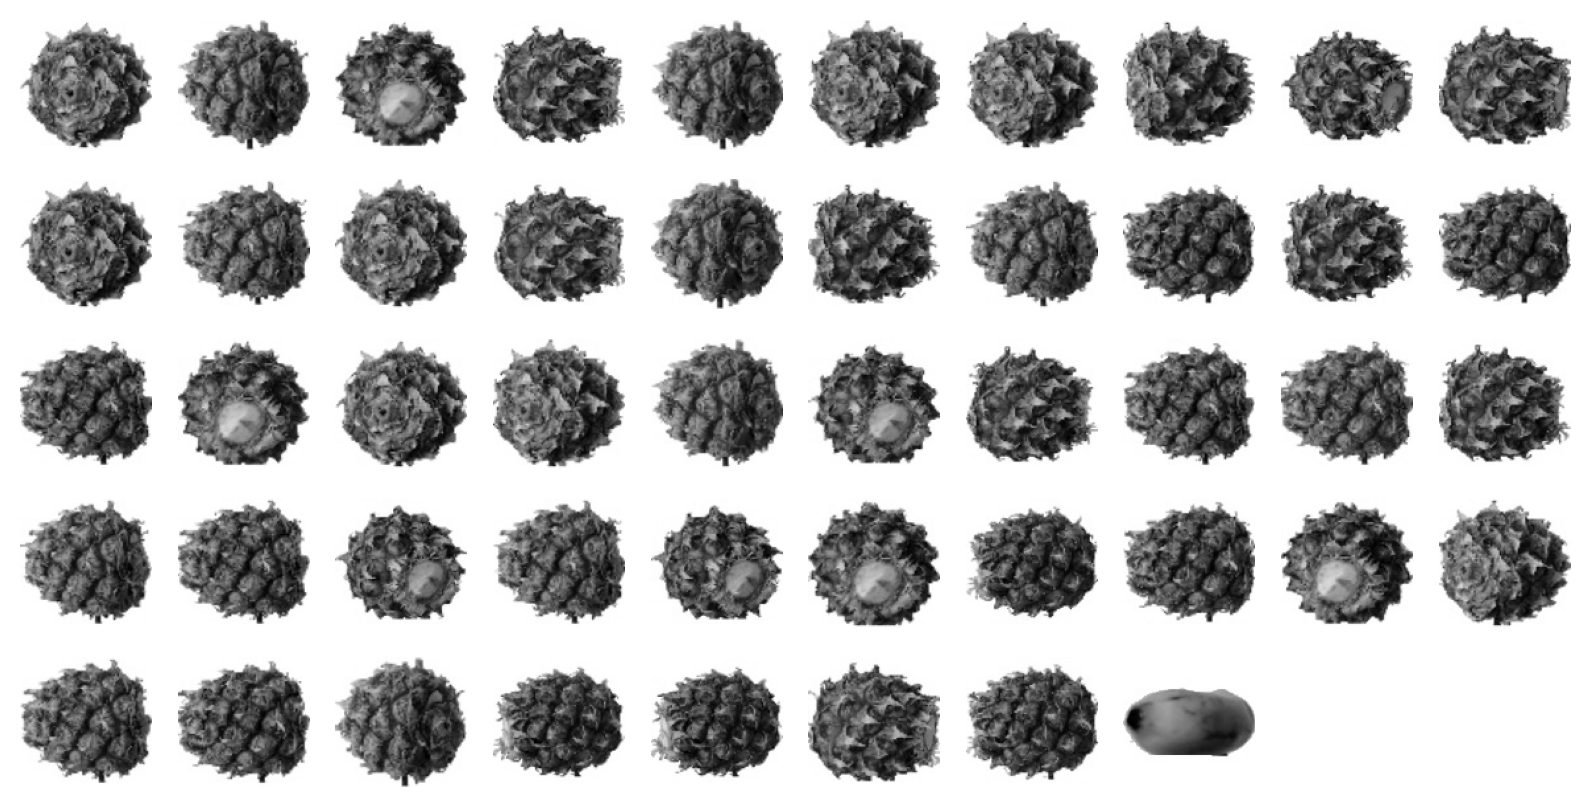

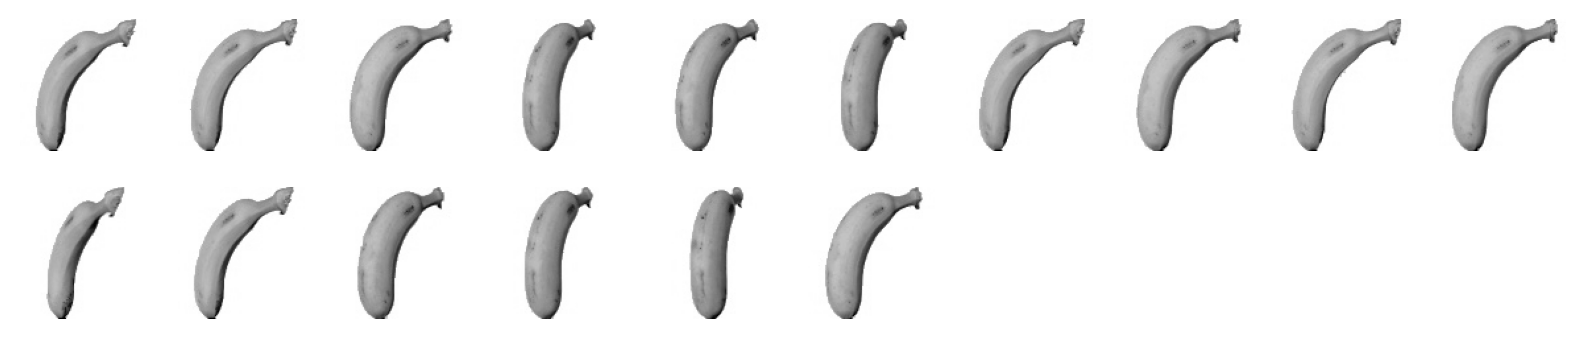

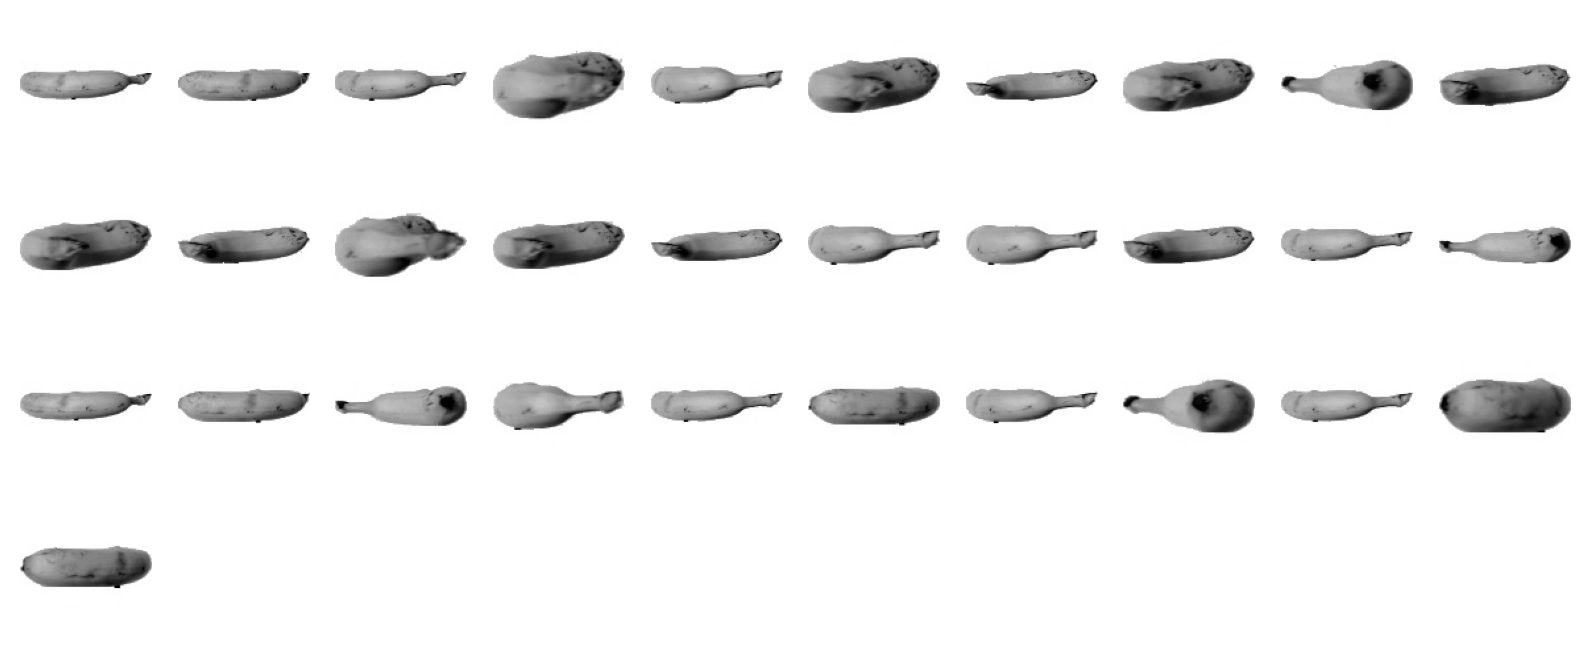

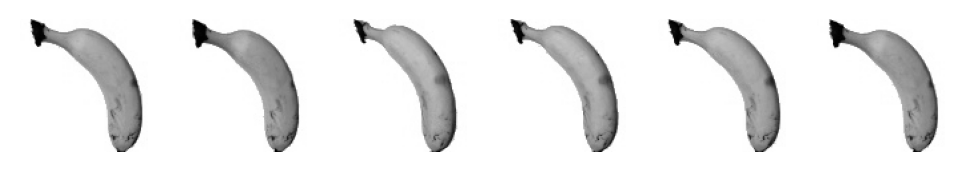

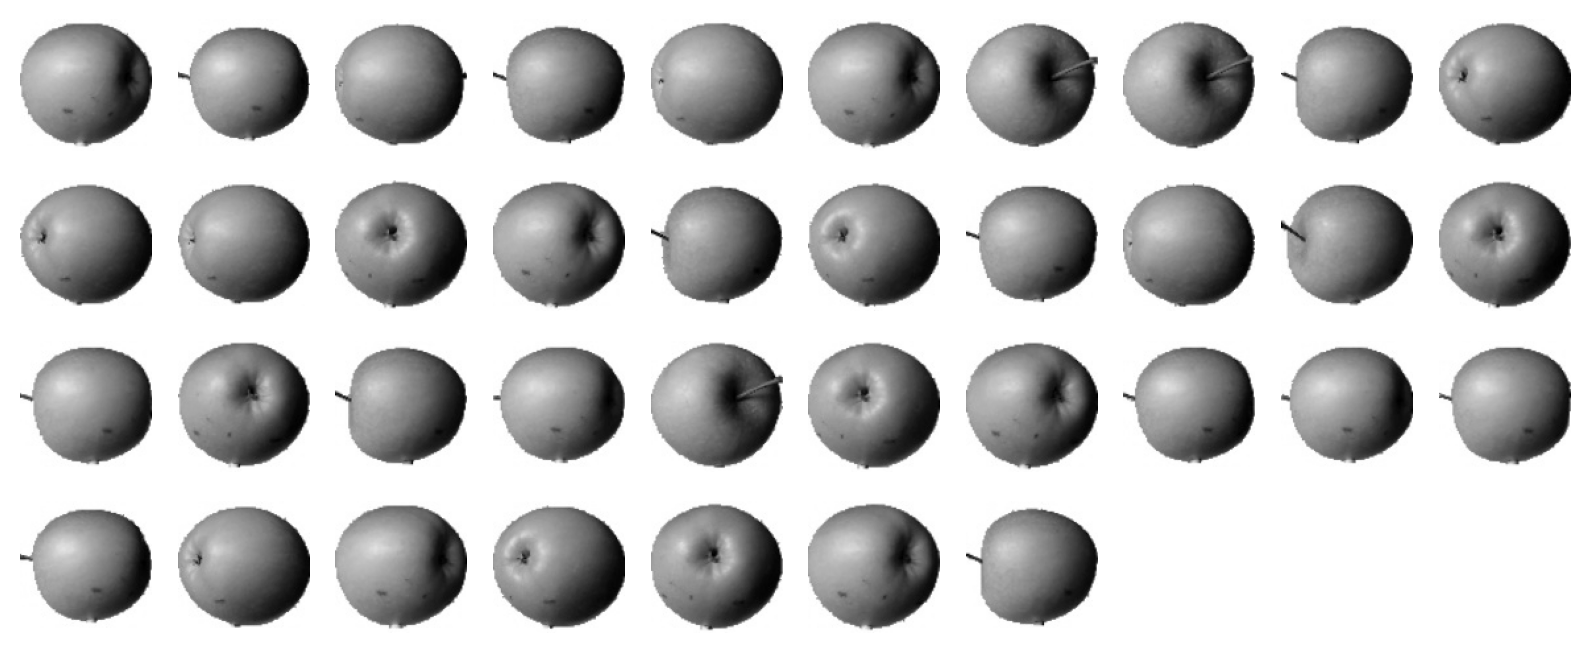

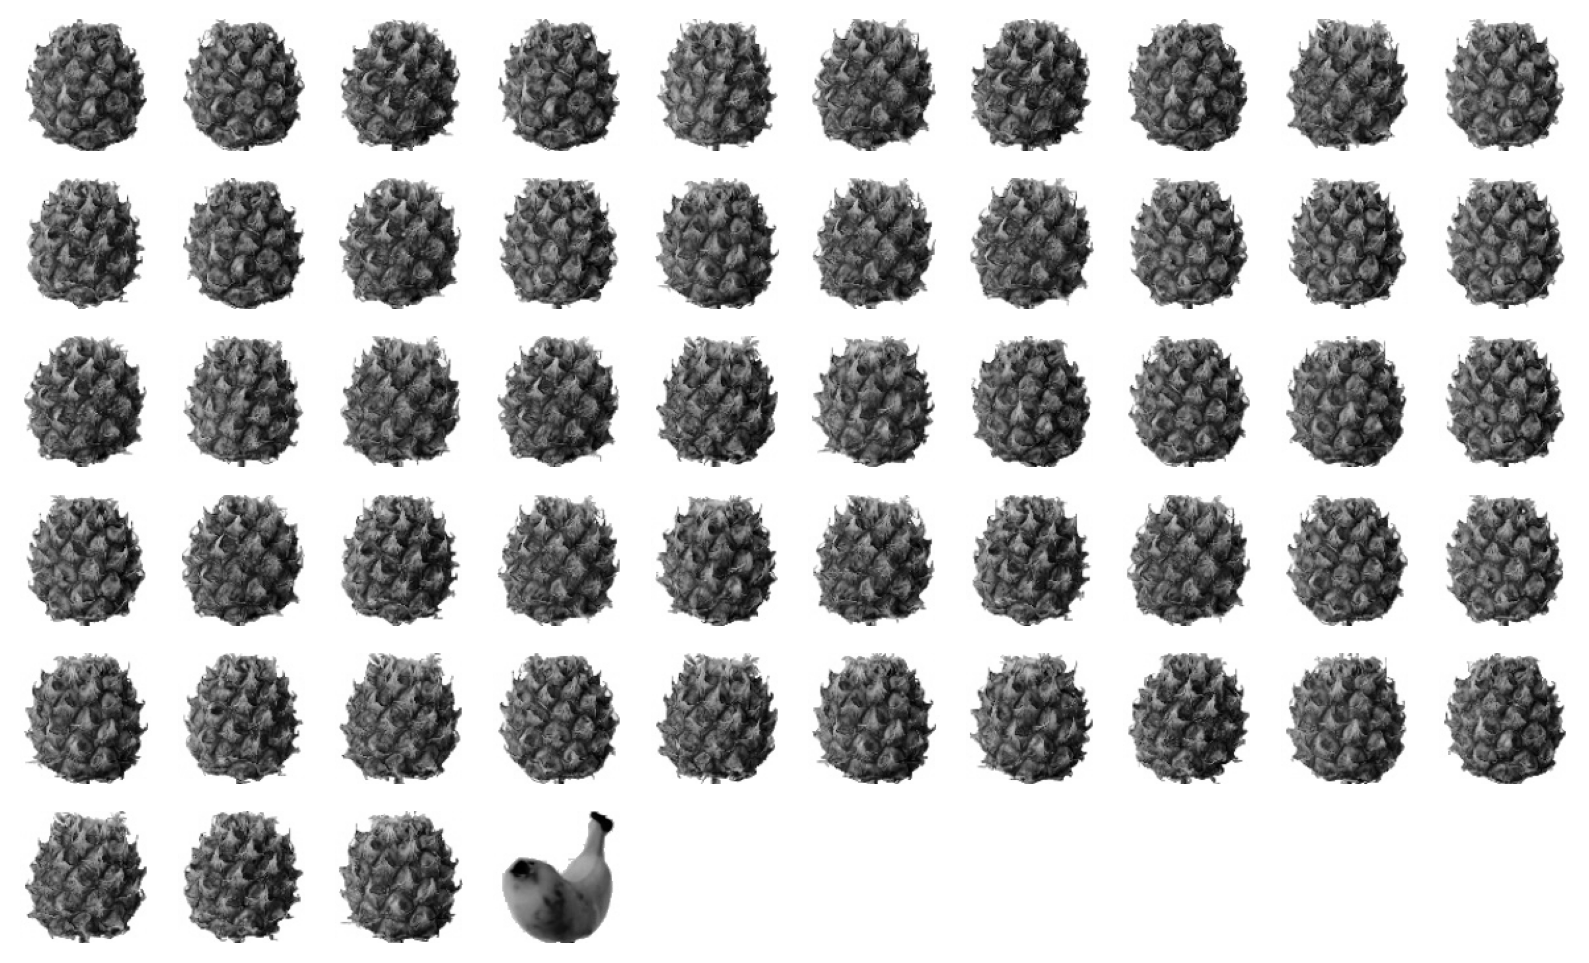

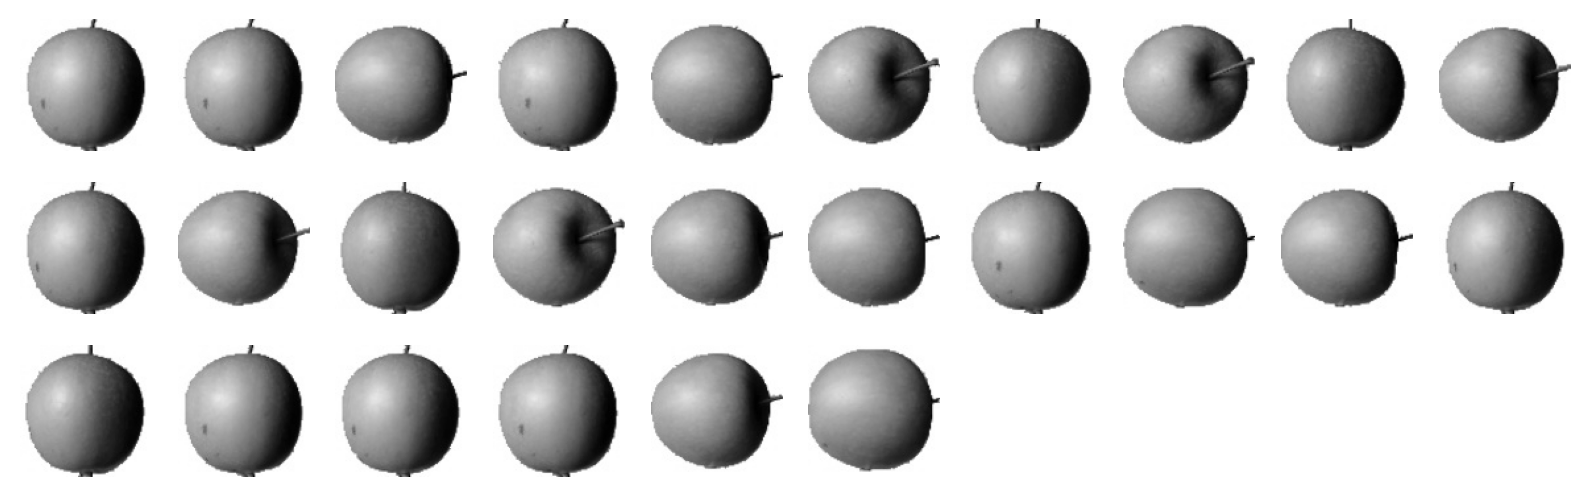

In [43]:
import numpy as np
#비지도학습: 클러스터링(군집 알고리즘). No타깃, 알고리즘이 데이터 더미 속 직접 패턴 및 구조를 학습하여 유사성을 기준으로 그룹화(클러스터) 분류하는 모델

fruits = np.load(r'C:\Machine\fruits_300.npy')
print(fruits.shape)

fruits_2d = fruits.reshape(-1, 100*100)
from sklearn.cluster import KMeans
km = KMeans(n_clusters=10, n_init = 'auto', random_state=42)
km.fit(fruits_2d)
print(km.labels_)
print(np.unique(km.labels_, return_counts=True))
result = km.labels_

import matplotlib.pyplot as plt
#그림 그리기. 축 개수 지정. 샘플 수, 행 개수, 열 개수
def draw_fruits(array, ratio=1):
    sample = int(len(array))
    col = sample if sample < 10 else 10
    row = int(np.ceil(sample/10))
    
    fig, axs = plt.subplots(row, col, figsize=(col*ratio, row*ratio), dpi=200, squeeze=False)
    n = 0
    for i in range(row):
        for j in range(col):
            if n < sample:
                axs[i, j].imshow(array[10*i+j], cmap='gray_r')
                n += 1
            axs[i, j].axis('off')
            
                
    fig.show()
draw_fruits(fruits[km.labels_ == 0])
draw_fruits(fruits[km.labels_== 1])
draw_fruits(fruits[km.labels_ == 2])
draw_fruits(fruits[km.labels_ == 3])
draw_fruits(fruits[km.labels_ == 4])
draw_fruits(fruits[km.labels_ == 5])
draw_fruits(fruits[km.labels_ == 8])
    


4


C:\Users\박중현\AppData\Local\Temp\ipykernel_15344\3422670689.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\박중현\AppData\Local\Temp\ipykernel_15344\3422670689.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


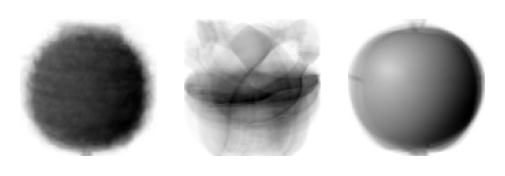

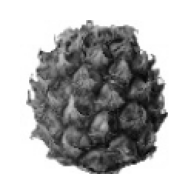

In [28]:
km.cluster_centers_.shape
draw_fruits(km.cluster_centers_.reshape(-1, 100, 100))
km.transform(fruits_2d[100:101])
km.predict(fruits_2d[100:101])
draw_fruits(fruits[100:101])
print(km.n_iter_)

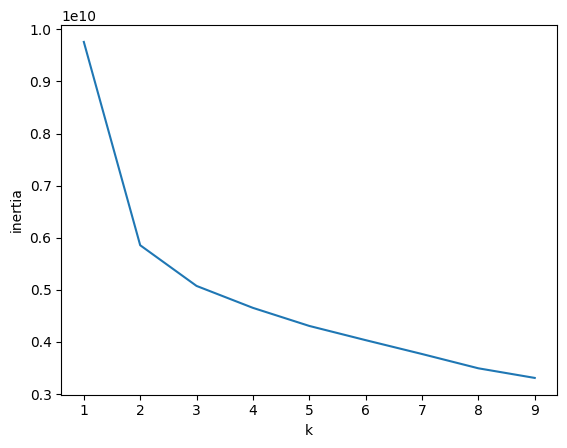

[9759303433.439999, 5856532545.983113, 5075273831.931918, 4654263679.536389, 4307297394.622732, 4034428491.557119, 3768343896.540716, 3494016156.1220245, 3309372578.4479575]


In [37]:
km.inertia_

inertia = []

for n in range(1, 10, 1):
    km_test = KMeans(n_clusters=n, n_init='auto', random_state=42)
    km_test.fit(fruits_2d)
    inertia.append(km_test.inertia_)

plt.plot(range(1, 10), inertia)
plt.xlabel('k')
plt.ylabel('inertia')
plt.show()
print(inertia)